In [95]:

import yfinance as yf

crypto_symbol = "BTC-USD"
prediction_ahead = 15

btc_data = yf.download(crypto_symbol, period='10y', interval='1d')
ser = btc_data
btc_data = btc_data['Close']
btc_data.shape

[*********************100%***********************]  1 of 1 completed


(3654, 1)

In [96]:
btc_data.head()

Ticker,BTC-USD
Date,
2015-04-30,236.145004
2015-05-01,232.078995
2015-05-02,234.929993
2015-05-03,240.358002
2015-05-04,239.018005


In [97]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(btc_data)


In [98]:
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]
print(train_data.shape)
print(test_data.shape)

(2923, 1)
(731, 1)


In [99]:
import numpy as np
def create_dataset(data, time_step = 1):
    X, y = [], []

    for i in range(len(data) - time_step):
        X.append(data[i: (i+time_step) ,0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)
    

In [100]:
time_step = 60
X_train, y_train = create_dataset(train_data, time_step=time_step)
X_test, y_test = create_dataset(test_data, time_step=time_step)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [101]:
X_test.shape

(671, 60, 1)

In [102]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Dropout,Input

model = Sequential()
model.add(Input(shape=(time_step, 1)))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, batch_size=1, epochs=5, verbose=1)

train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

train_preds = scaler.inverse_transform(train_preds)
y_train = scaler.inverse_transform(y_train.reshape(-1,1))

test_preds = scaler.inverse_transform(test_preds)
y_test = scaler.inverse_transform(y_test.reshape(-1,1))

Epoch 1/5
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 121s 40ms/step - loss: 0.0020
Epoch 2/5
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 142s 40ms/step - loss: 7.2563e-04
Epoch 3/5
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 140s 49ms/step - loss: 7.0165e-04
Epoch 4/5
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 118s 41ms/step - loss: 6.1541e-04
Epoch 5/5
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 114s 40ms/step - loss: 5.4399e-04
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [103]:
print(btc_data.index[train_size:train_size + len(test_preds)])
print(train_preds.shape)

DatetimeIndex(['2023-05-01', '2023-05-02', '2023-05-03', '2023-05-04',
               '2023-05-05', '2023-05-06', '2023-05-07', '2023-05-08',
               '2023-05-09', '2023-05-10',
               ...
               '2025-02-20', '2025-02-21', '2025-02-22', '2025-02-23',
               '2025-02-24', '2025-02-25', '2025-02-26', '2025-02-27',
               '2025-02-28', '2025-03-01'],
              dtype='datetime64[ns]', name='Date', length=671, freq=None)
(2863, 1)


In [104]:
# forecast future

last_60_days = scaled_data[-time_step:]
future_input = last_60_days.reshape(1, time_step, 1)
future_forecast = []

for _ in range(prediction_ahead):
    next_pred = model.predict(future_input)[0,0]
    future_forecast.append(next_pred)
    next_input = np.append(future_input[0,1:], [[next_pred]], axis=0)
    future_input = next_input.reshape(1, time_step, 1)

future_forecast = scaler.inverse_transform(np.array(future_forecast).reshape(-1,1))

latest_closed_price = float(ser['Close'].iloc[-1])
latest_predicted_price = future_forecast[-1]
print(f"the latest close price: {latest_closed_price}")
print(f"the latest predicted price: {latest_predicted_price}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
the latest close price: 95103.1484375
the latest predicted price: [40323.48]


C:\Users\A cer\AppData\Local\Temp\ipykernel_18452\4213718824.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  latest_closed_price = float(ser['Close'].iloc[-1])


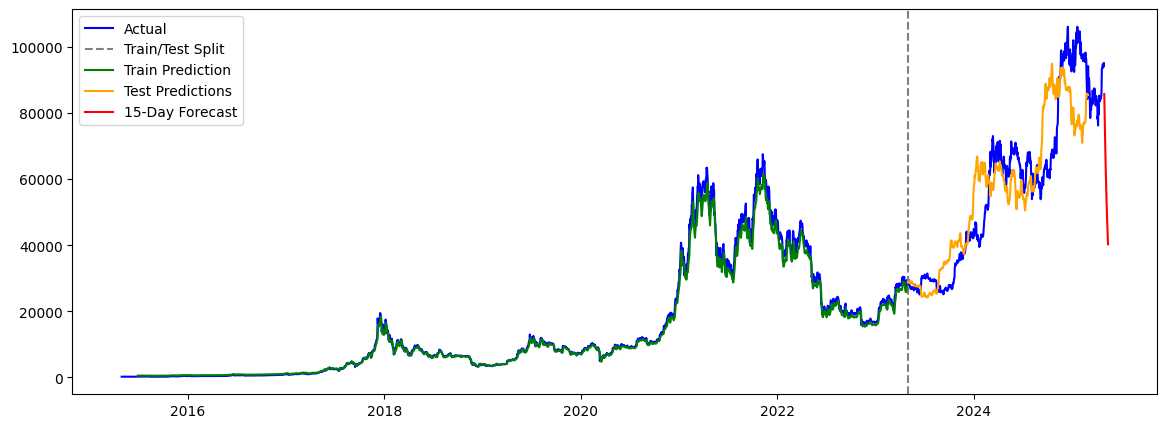

In [105]:
import matplotlib.pyplot as plt
import pandas as pd
plt.figure(figsize=(14,5))
plt.plot(btc_data.index, btc_data['BTC-USD'], label='Actual', color='blue')
plt.axvline(x=btc_data.index[train_size], color='gray', linestyle='--', label='Train/Test Split')

train_range = btc_data.index[time_step:train_size]
test_range = btc_data.index[train_size:train_size + len(test_preds)]

plt.plot(train_range, train_preds[:len(train_range)], label='Train Prediction', color='green')
plt.plot(test_range, test_preds[:len(test_range)], label="Test Predictions", color='orange')

future_index = pd.date_range(start=btc_data.index[-1], periods=prediction_ahead+1, freq='D')[1:]
plt.plot(future_index, future_forecast, label=f'{prediction_ahead}-Day Forecast', color='red')
plt.legend()
plt.show()